In [1]:
import sys
sys.path.append('..')
import os
import torch
import pickle
import json
from pathlib import Path
import numpy as np
from expl_perf_drop.data import cmnist
from expl_perf_drop.models import select as model_select
from expl_perf_drop.utils import Tee, eval_metrics

/opt/conda/envs/expl_perf_drop/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
#device = 'cpu' #cmnist no set it for GPU 
output_dir = './models'
output_model_path = os.path.join(output_dir,'cmnist_model.pkl')
hparams = {'data_seed': 42, 'data_dir': '../expl_perf_drop/data/celebA', 'test_pct': 0.25, 'model':'nn', 'dataset':'cmnist', 'debug':False}
cmnist_data = cmnist.CMNIST(hparams)

In [3]:
train_df, test_df = cmnist_data.get_source_train_test()

/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/data/cmnist.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'X{i}'] = X[:, i]
/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/data/cmnist.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'X{i}'] = X[:, i]
/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/data/cmnist.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

In [4]:
model = model_select(hparams['model'], cmnist_data.TASK_TYPE, hparams, device).fit(train_df[cmnist_data.TRAIN_FEATURES], train_df[cmnist_data.TARGET_NAME])

/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/models.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(-1), torch.ones((len(y), 1), device=self.device))


In [5]:
pickle.dump(model, open(output_model_path, 'wb'))
pickle.dump(eval_metrics(test_df[cmnist_data.TARGET_NAME], model, cmnist_data.TASK_TYPE, cmnist_data.TRAIN_FEATURES, test_df), 
        open(os.path.join(output_dir,'stats.pkl'), 'wb'))

with open(os.path.join(output_dir, 'done'), 'w') as f:
    f.write('done')


with open(os.path.join(output_dir,'args.json'), 'w') as f:
    json.dump(hparams, f, indent = 4)


## Explanations

In [6]:
from expl_perf_drop.explainers import CGExplainerDR
from expl_perf_drop.utils import Graph
from expl_perf_drop.metrics import select as metric_select
from expl_perf_drop.data import select as data_select

In [7]:
hparams_explain = {'dataset': ['cmnist'], 'graph':{'exp1': ["normal"],},'method':{'exp1': ['ours'],},'model_dir': output_dir, 'dataset': 'cmnist', 'metric':'acc','debug': False}
hparams_explain


{'dataset': 'cmnist',
 'graph': {'exp1': ['normal']},
 'method': {'exp1': ['ours']},
 'model_dir': './models',
 'metric': 'acc',
 'debug': False}

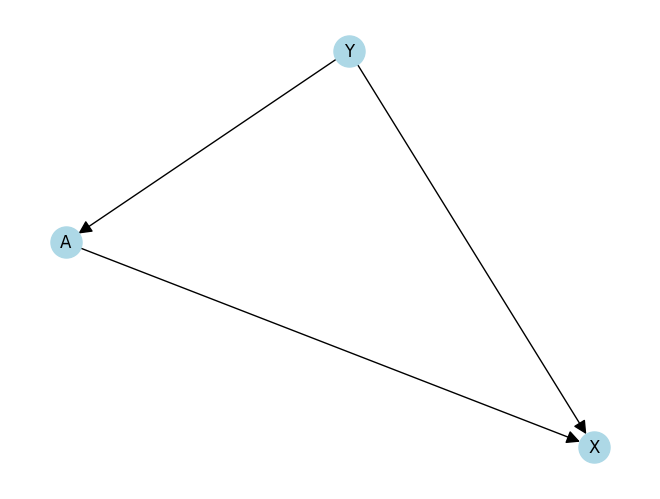

In [8]:
graph = cmnist_data.GRAPH
# Pedro palys with the graph
import networkx as nx
import matplotlib.pyplot as plt


# Draw the graph
nx.draw(graph.to_directed(), with_labels=True, node_color='lightblue', 
        node_size=500, arrowsize=20)
plt.show()

In [9]:
model_dir = Path(hparams_explain['model_dir'])
model_train_hparams = json.load((model_dir/'args.json').open('r'))
model = pickle.load((model_dir/'cmnist_model.pkl').open('rb'))
hparams['model_train_hparams'] = model_train_hparams
hparams = {**hparams, **{
            'cmnist_label_prob': 0.5,
            'cmnist_color_prob': 0.8, # orinally 0.15 so the P(A|Y should explain mostly everythong in this setting)
            'cmnist_flip_prob': 0.25,
        }}

assert model_train_hparams['dataset'] == hparams['dataset']

In [10]:
metric = metric_select(hparams_explain['metric'])

In [11]:
source_train_df, source_eval_df  = train_df, test_df 
target_train_df, target_eval_df = cmnist_data.get_target_train_test(hparams)

/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/data/cmnist.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'X{i}'] = X[:, i]
/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/data/cmnist.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'X{i}'] = X[:, i]
/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/data/cmnist.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

In [16]:
from expl_perf_drop.torch_utils import select_with_wrapper
cont_model = model_select('xgb', 'regression')
#dis_model = model_select('xgb', 'classification', hparams=hparams)
dis_model = model_select('nn', 'classification', hparams, device)
clip_weight_thres = None
clip_prob_thres = 0.999999
calibrate_weight_models = False
imp_weight_type = 'normal'
shapley_method = "AUTO"

In [17]:
exp = CGExplainerDR(graph, source_train_df, source_eval_df, target_train_df, target_eval_df,
            cmnist_data.TRAIN_FEATURES, cmnist_data.VAR_CATEGORIES, cmnist_data.TARGET_NAME, dis_model, cont_model, calibrate_weight_models = calibrate_weight_models,
            clip_weight_thres = clip_weight_thres, clip_prob_thres = clip_prob_thres, imp_weight_type = imp_weight_type,
            shapley_method = shapley_method)

perfs = exp.get_perf_on_sets(model, metric)
print(perfs)
print(exp.get_all_possible_shifts())
res = exp.explain(model, metric)
scaled_res = exp.scale(res, perfs)

{'source': 0.8204, 'target': 0.3436}
['Y', (frozenset({'Y'}), 'A'), (frozenset({'Y', 'A'}), 'X')]


/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/models.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(-1), torch.ones((len(y), 1), device=self.device))
/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/models.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(-1), torch.ones((len(y), 1), device=self.device))
/home/jovyan/workspace/expl_perf_drop/examples/../expl_perf_drop/models.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach

_delta [(frozenset({'Y'}), 'A'), (frozenset({'Y', 'A'}), 'X')]
_delta ['Y']
_delta [(frozenset({'Y'}), 'A')]
_delta []
_delta ['Y', (frozenset({'Y'}), 'A'), (frozenset({'Y', 'A'}), 'X')]
_delta ['Y', (frozenset({'Y', 'A'}), 'X')]
_delta ['Y', (frozenset({'Y'}), 'A')]
_delta [(frozenset({'Y', 'A'}), 'X')]
Finished evaluating 8 subsets. {(0, 0, 0): 0.0, (0, 0, 1): -0.015555418440859281, (0, 1, 0): -0.4670598200406325, (0, 1, 1): -0.3463082786732989, (1, 0, 0): 2.3362154398687274e-05, (1, 0, 1): -0.015267615194146655, (1, 1, 0): -0.4669566365565148, (1, 1, 1): -0.3463898628395035}


In [14]:
final = {'perfs': perfs, 'expl': res, 'scaled_expl': scaled_res}


In [15]:
final

{'perfs': {'source': 0.8204, 'target': 0.3436},
 'expl': P(Y)          0.000059
 P(A | Y)     -0.471744
 P(X | A,Y)    0.016084
 dtype: float64,
 'scaled_expl': P(Y)          0.000062
 P(A | Y)     -0.493695
 P(X | A,Y)    0.016833
 dtype: float64}